In [1]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
import causalpy as cp
import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide s

In [2]:
myPredictorsDf = pd.read_csv('../predictorsDf.csv')

In [10]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myYValue = myPredictorsDf['CPC12']
X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.30)

In [4]:
myGridSearchCv = gridSearchKFoldRegression(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='r2')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), 'clf__max_depth': 2, 'clf__n_estimators': 10}
Best cross val r2 score: 0.1293
R2 score  on test set: 0.15812555768840486


In [17]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': LogisticRegression(), 'clf__C': 0.1}
Best cross val roc_auc score: 0.8290
Area under the receiver operating curve on test set is 0.9023
Accuracy score on test set is 0.9316


C:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


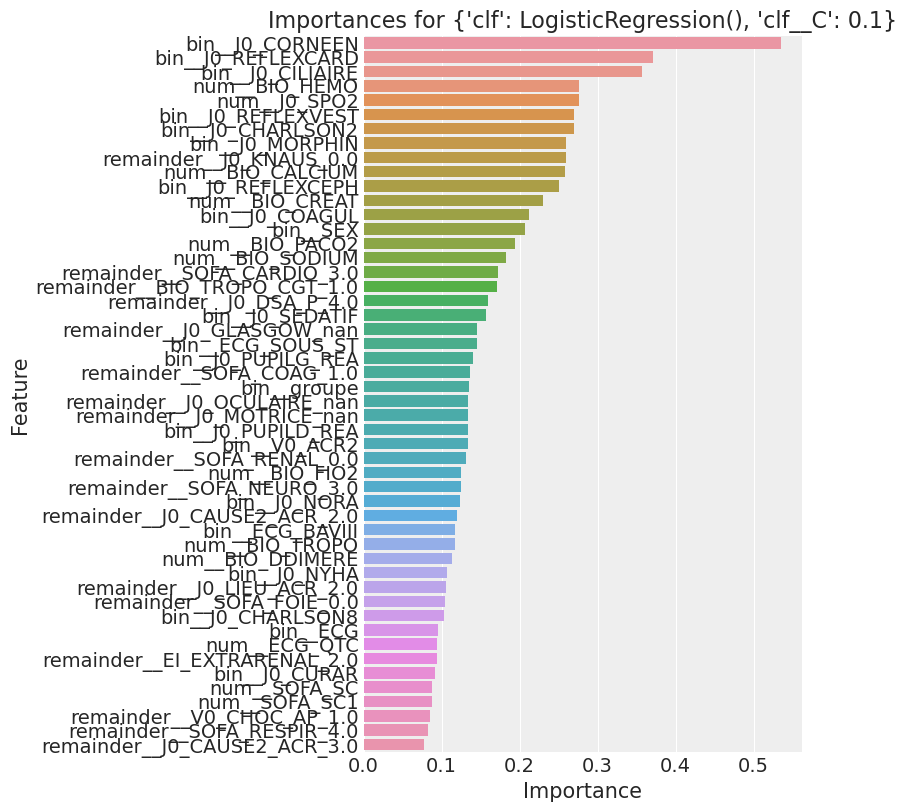

In [18]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps['preprocessor'].get_feature_names_out()), X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.231801
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.231046
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.5586946360008938
p-value: 0.7562771889139482
Degress of freedom: 2.0


C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_catego

0.7562771889139482

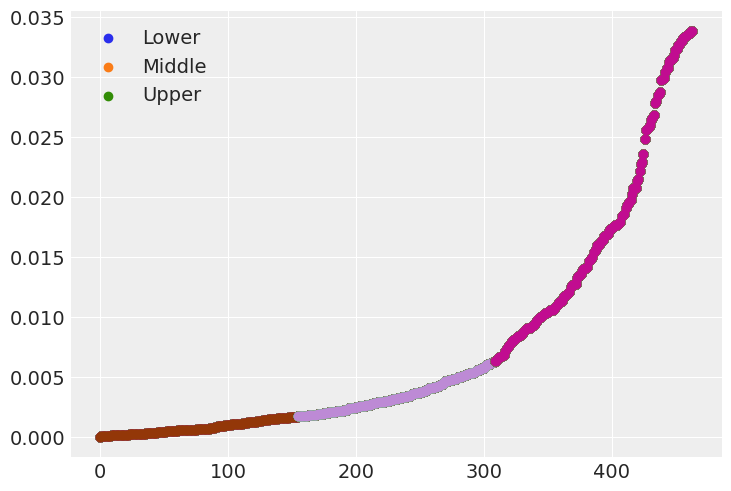

In [20]:
getTreatmentEffectDiff(X_train, y_train, myBestModel)

In [13]:
myBestModel = None
myBestPValue = 1
myBestData = None
myBestKMeans = None
myDroppedColumns = None
myRemainingColumns = None
myNumDroppedColumns = 0

# Still need stratified k-fold, maybe I fit with all data and test against each of the folds 
for i in range(200):
    myNumColumsToDrop = random.randint(1, len(X_train.columns) - 4)
    myNewXValue = X_train.copy()
    myNewXValue = myNewXValue.drop(columns=['groupe'])
    myColumnsToDrop = myNewXValue.sample(n=myNumColumsToDrop, axis=1).columns
    myNewXValue.drop(columns = myColumnsToDrop, inplace=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = myNewXValue)
    myPipelineSteps.append(('clf', AgglomerativeClustering(n_clusters=random.randint(2, 7))))
    myPipeline = Pipeline(myPipelineSteps)
    try:
        p_value, myModel, myData = getTreatmentEffectDiffUnsupervised(X_train, y_train, myPipeline) 
        if p_value + len(myNewXValue.columns) / (3 *len(X_train.columns))  < myBestPValue:
            myBestPValue = p_value
            myBestModel = myModel
            myBestData = myData
            myBestKMeans = myPipeline
            myRemainingColumns = myNewXValue.columns
            myDroppedColumns = myColumnsToDrop
            myNumDroppedColumns = myNumColumsToDrop
    except:
        print('Failed')
        continue

# p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(X_test, y_test, myBestKMeans)
# plotPredictedEffectDiff(aData = myData, aBestModel = myModel)

Optimization terminated successfully.
         Current function value: 0.263888
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.257614
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 3.538401840772565
p-value: 0.05996321089420136
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263778
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263777
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.0008214292810748702
p-value: 0.9771352899906454
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.260631
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.258804
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.0303550903410894
p-value: 0.3100752817595966
Degress of freedom: 1.0
Opti

C:\Program Files\miniconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.262102
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.258399
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 2.0882161989105157
p-value: 0.1484393038253027
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263330
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263322
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.004216816237260446
p-value: 0.9482241471041052
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.261214
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.261213
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.0007902865988569374
p-value: 0.9775727940915101
Degress of freedom: 1.0
Op

C:\Program Files\miniconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.258777
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.248906
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 5.567653927151781
p-value: 0.01829525784228355
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263953
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263579
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.210990559229856
p-value: 0.6459921193075766
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263423
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.260828
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.4633569954709742
p-value: 0.22639674209570837
Degress of freedom: 1.0
Optimiz

...

C:\Program Files\miniconda3\lib\site-packages\statsmodels\discrete\discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Optimization terminated successfully.
         Current function value: 0.261343
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.259434
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.076857038366171
p-value: 0.29940172341673144
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.262721
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.260907
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.0232348192556913
p-value: 0.3117529279252993
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263823
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.260849
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.6773928412908674
p-value: 0.1952712430656308
Degress of freedom: 1.0
Optimiz

C:\Program Files\miniconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.260480
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.251241
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 5.211061354050457
p-value: 0.022443629777044772
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.259686
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.254752
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 2.7828890450539916
p-value: 0.09527616146410946
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263933
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.261627
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.3008829761818106
p-value: 0.2540520008332963
Degress of freedom: 1.0
Optim

Optimization terminated successfully.
         Current function value: 0.254930
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.251037
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 2.195903488466655
p-value: 0.13837805048998117
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.263354
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.257899
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 3.0767367796334497
p-value: 0.07941972386894952
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.257618
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.255680
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 1.0927450657779048
p-value: 0.2958637904454642
Degress of freedom: 1.0
Optimi

Optimization terminated successfully.
         Current function value: 0.263841
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.249029
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 8.354142782410406
p-value: 0.003848089633630062
Degress of freedom: 1.0


C:\Users\mbranda1\lcicm\analysisFunctions\machine_learning.py:283: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


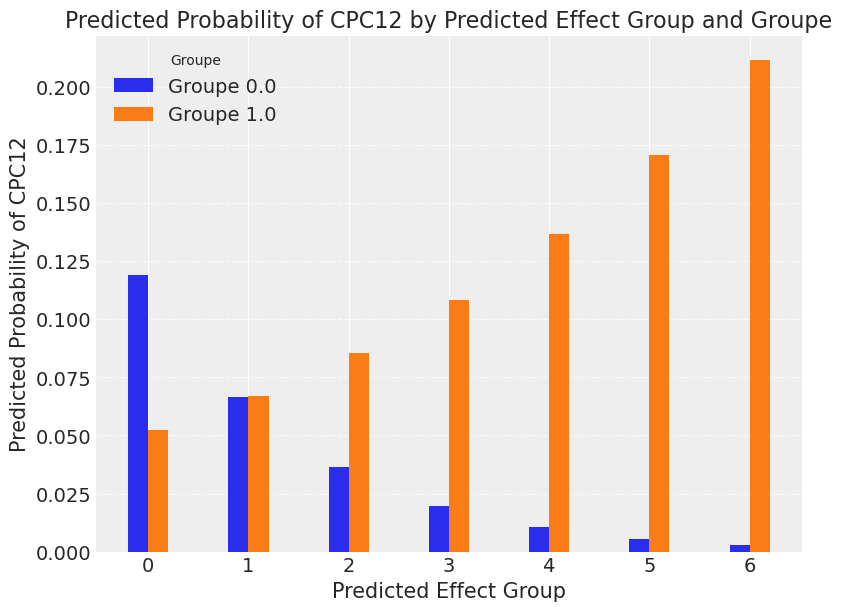

Dropped Columns: Index(['SOFA_SC', 'J0_LIEU_ACR', 'SOFA_SC1', 'ECG_FLUTER', 'J0_ATCD',
       'ECG_SALV_VENT', 'V0_PLANCHE', 'EI_CONVULS', 'EI_OAP', 'J0_CHARLSON7',
       ...
       'J0_BMI', 'BIO_TROPO2', 'EI_ARYTHMI', 'SEX', 'J0_BICARB', 'BIO_CALCIUM',
       'ECG_QTC', 'BIO_TP', 'J0_CHARLSON4', 'BIO_PACO2'],
      dtype='object', length=143)
Remaining Columns: Index(['J0_PUPILG', 'J0_CHARLSON8', 'J0_CHARLSON13', 'V0_CHARLSON19',
       'V0_CHOC_AV', 'V0_THROMBO', 'J0_AMINE', 'J0_DOBU', 'J0_PEP',
       'BIO_LEUCO', 'BIO_HEMO', 'BIO_PAO2', 'ECG_BBD', 'ECG_SALV_SUPRA'],
      dtype='object')
Num Dropped Columns: 143


In [14]:
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(X_train, y_train, myBestKMeans)
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)
print(f'Dropped Columns: {myDroppedColumns}')
print(f'Remaining Columns: {myRemainingColumns}')
print(f'Num Dropped Columns: {myNumDroppedColumns}')

Optimization terminated successfully.
         Current function value: 0.315792
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.304646
         Iterations 9
Likelihood ratio of test results:
Chi square statistic: 1.226042311865335
p-value: 0.26817809710834606
Degress of freedom: 1.0


C:\Users\mbranda1\lcicm\analysisFunctions\machine_learning.py:283: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


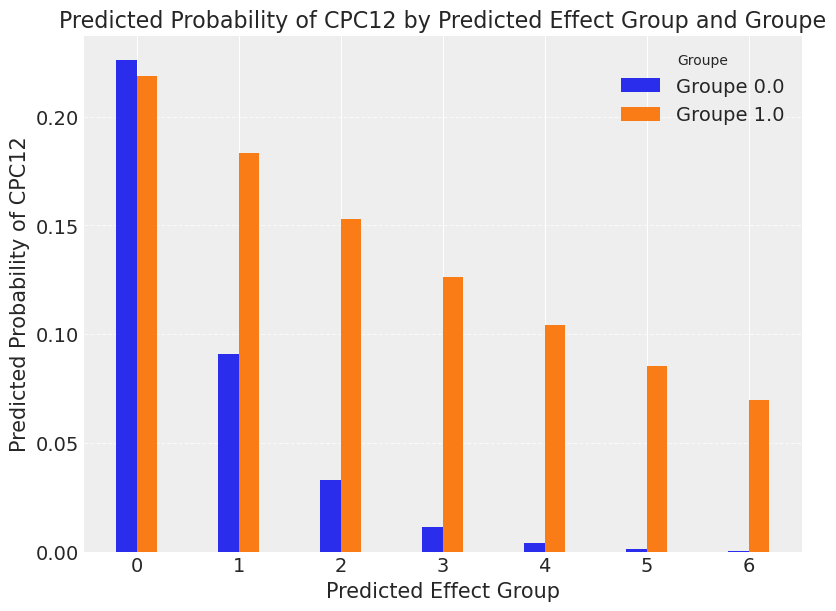

Number of Clusters: 7
Dropped Columns: Index(['SOFA_SC', 'J0_LIEU_ACR', 'SOFA_SC1', 'ECG_FLUTER', 'J0_ATCD',
       'ECG_SALV_VENT', 'V0_PLANCHE', 'EI_CONVULS', 'EI_OAP', 'J0_CHARLSON7',
       ...
       'J0_BMI', 'BIO_TROPO2', 'EI_ARYTHMI', 'SEX', 'J0_BICARB', 'BIO_CALCIUM',
       'ECG_QTC', 'BIO_TP', 'J0_CHARLSON4', 'BIO_PACO2'],
      dtype='object', length=143)
Remaining Columns: Index(['J0_PUPILG', 'J0_CHARLSON8', 'J0_CHARLSON13', 'V0_CHARLSON19',
       'V0_CHOC_AV', 'V0_THROMBO', 'J0_AMINE', 'J0_DOBU', 'J0_PEP',
       'BIO_LEUCO', 'BIO_HEMO', 'BIO_PAO2', 'ECG_BBD', 'ECG_SALV_SUPRA'],
      dtype='object')
Num Dropped Columns: 143


In [15]:
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(X_test, y_test, myBestKMeans)
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)
print(f'Number of Clusters: {myBestKMeans.named_steps.clf.n_clusters}')
print(f'Dropped Columns: {myDroppedColumns}')
print(f'Remaining Columns: {myRemainingColumns}')
print(f'Num Dropped Columns: {myNumDroppedColumns}')